# Contents

1. Objective
2. Import Libraries
3. Load Dataset
4. Data Understanding
5. Data Cleaning
6. Feature Engineering
7. Exploratory Data Analysis
8. Key Findings
9. Business Recommendations
10. Conclusion

In [2]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("hotel_bookings.csv")

# Display first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [8]:
df.duplicated().sum()

np.int64(31994)

# Data Understanding

The dataset was explored to understand its structure, identify missing values, detect duplicate records, and review data types before beginning data cleaning and analysis.

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


## Handling Missing Values

The dataset contains missing values in a few columns. Each column is handled based on its meaning rather than deleting rows, ensuring that valuable booking information is retained for analysis.

In [19]:
# Fill missing values

df["children"] = df["children"].fillna(0)

df["country"] = df["country"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [20]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Cleaning Summary

- Missing values in **children** were replaced with 0 because a missing value indicates no child information was recorded.
- Missing values in **country** were replaced with "Unknown" to preserve booking records while indicating unavailable location information.
- Missing values in **agent** and **company** were replaced with 0 because these bookings were not associated with an agent or company.

The dataset is now complete and ready for analysis.

# Feature Engineering

In [21]:
# Create Total Guests column

df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0


In [22]:
# Create Total Nights column

df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2


### Feature Engineering Summary

Two new features were created:

- **total_guests**: Total number of guests in each booking.
- **total_nights**: Total duration of each stay.

These features simplify later analyses of customer behavior and booking patterns.

# Exploratory Data Analysis (EDA)

## Business Question 1

Which hotel type receives the highest number of bookings?

In [23]:
hotel_bookings = df["hotel"].value_counts()

hotel_bookings

,count
hotel,
City Hotel,79330
Resort Hotel,40060


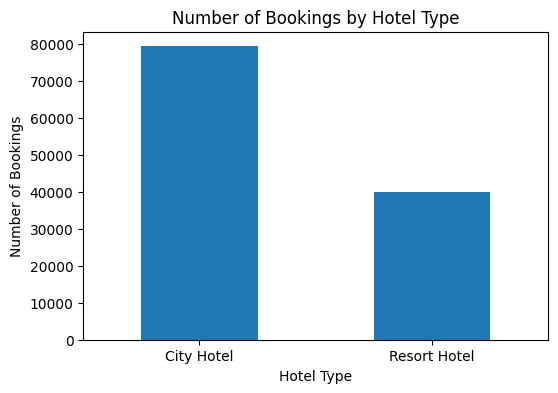

In [24]:
hotel_bookings.plot(kind="bar", figsize=(6,4))

plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

### Business Insight

City Hotels receive significantly more bookings than Resort Hotels, indicating higher demand for urban accommodations.

### Recommendation

Travel companies should strengthen partnerships with city hotels while creating promotional offers to boost resort hotel bookings during off-peak seasons.

## Business Question 2

Which month receives the highest number of bookings?

In [25]:
month_bookings = df["arrival_date_month"].value_counts()

month_bookings

,count
arrival_date_month,
August,13877
July,12661
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


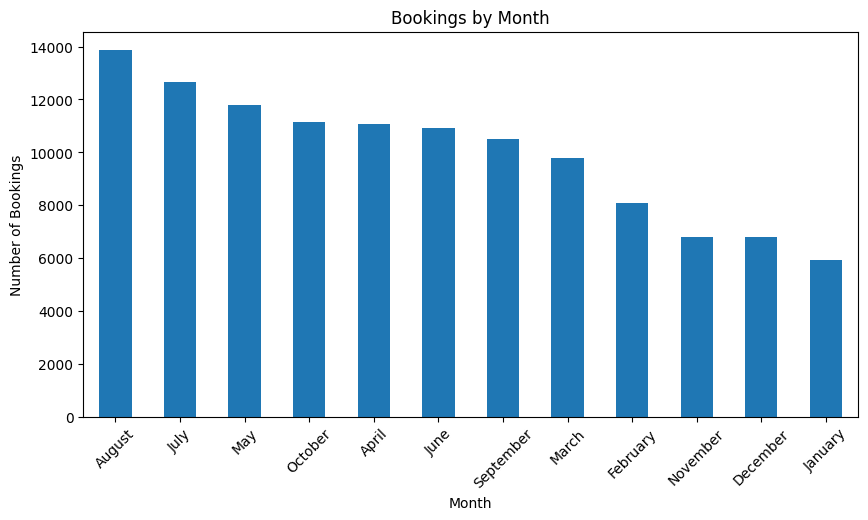

In [26]:
month_bookings.plot(kind="bar", figsize=(10,5))

plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

### Business Insight

Booking demand varies significantly across different months, indicating strong seasonal travel patterns.

### Recommendation

Increase staffing, marketing campaigns, and hotel inventory during peak booking months to maximize revenue and customer satisfaction.

## Business Question 3

Which customer type has the highest cancellation rate?

In [27]:
cancelled = df[df["is_canceled"] == 1]

cancelled["customer_type"].value_counts()

,count
customer_type,
Transient,36514
Transient-Party,6389
Contract,1262
Group,59


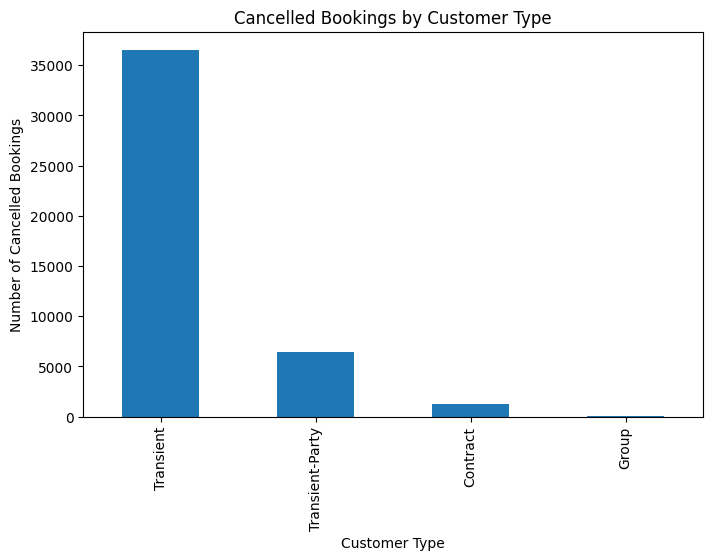

In [28]:
cancelled["customer_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cancelled Bookings by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Cancelled Bookings")

plt.show()

### Business Insight

Some customer types are more likely to cancel bookings than others. Understanding cancellation behavior can help businesses reduce revenue loss.

### Recommendation

Offer personalized promotions, flexible booking policies, or reminder notifications for customer groups with higher cancellation rates.

## Business Question 4

Which market segment contributes the highest number of bookings?

In [29]:
market_segment = df["market_segment"].value_counts()

market_segment

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


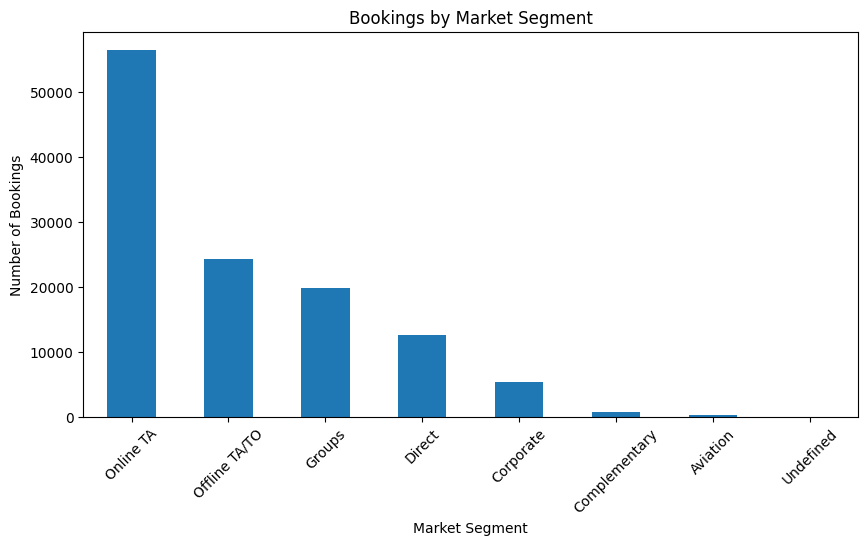

In [30]:
market_segment.plot(kind="bar", figsize=(10,5))

plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

### Business Insight

The Online Travel Agent (OTA) market segment contributes the highest number of bookings, highlighting the importance of online booking platforms in the travel industry.

### Recommendation

Strengthen partnerships with high-performing booking channels while exploring opportunities to improve direct bookings through loyalty programs and promotional offers.

## Business Question 5

Which countries contribute the highest number of hotel bookings?

In [31]:
top_countries = df["country"].value_counts().head(10)

top_countries

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
ITA,3766
IRL,3375
BEL,2342
BRA,2224


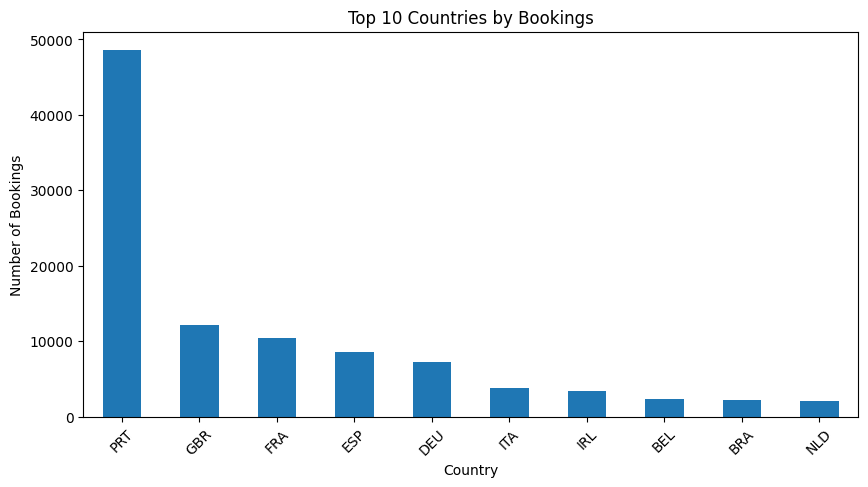

In [32]:
top_countries.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

### Business Insight

A small number of countries account for a significant share of bookings, indicating key geographic markets for the business.

### Recommendation

Develop targeted marketing campaigns and personalized travel offers for customers from these high-demand countries.

## Business Question 6

Do customers who book earlier tend to cancel more frequently?

In [33]:
cancelled = df[df["is_canceled"] == 1]
not_cancelled = df[df["is_canceled"] == 0]

print("Average Lead Time (Cancelled):", cancelled["lead_time"].mean())

print("Average Lead Time (Not Cancelled):", not_cancelled["lead_time"].mean())

Average Lead Time (Cancelled): 144.84881512301013
Average Lead Time (Not Cancelled): 79.98468722560732


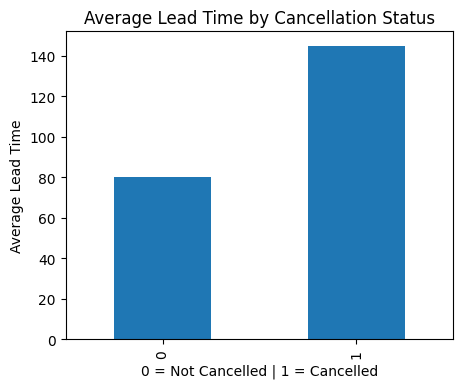

In [34]:
lead_time = df.groupby("is_canceled")["lead_time"].mean()

lead_time.plot(kind="bar", figsize=(5,4))

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("0 = Not Cancelled | 1 = Cancelled")
plt.ylabel("Average Lead Time")

plt.show()

### Business Insight

Bookings made well in advance generally show a higher tendency to be cancelled. This suggests that longer lead times may increase booking uncertainty.

### Recommendation

Travel companies can reduce cancellation risk by offering reminder emails, flexible modification options, or incentives for customers who confirm early bookings.

# Key Findings

- City Hotels received the highest number of bookings.
- Booking demand showed clear seasonal patterns across different months.
- Certain customer types were more likely to cancel reservations.
- Online Travel Agents (OTA) generated the highest number of bookings.
- A small number of countries contributed the majority of bookings.
- Longer booking lead times were associated with higher cancellation rates.

# Business Recommendations

- Increase marketing efforts during peak travel months.
- Strengthen partnerships with Online Travel Agents.
- Implement strategies to reduce booking cancellations.
- Develop country-specific promotional campaigns.
- Improve customer retention through personalized offers.
- Monitor lead times to proactively reduce cancellations.

# Conclusion

This analysis demonstrates how exploratory data analysis can uncover meaningful business insights from travel booking data. By applying Python, data cleaning, visualization, and statistical analysis techniques, valuable recommendations were generated to support business decision-making in the travel industry.